# Machine Learning Analysis – Retail Sales Prediction

## Objectives

* ## Machine Learning Objective

The objective of this notebook is to build a predictive machine learning model capable of estimating total sales amount using transaction-related features such as quantity and unit price.

This analysis aims to demonstrate how machine learning can support retail forecasting and business decision-making.


---

In [38]:
import os
current_dir = os.getcwd()
current_dir

'c:\\'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [39]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [40]:
current_dir = os.getcwd()
current_dir

'c:\\'

# ML Model

# The varible is for the total amount 
# The feautures are quantity and unitprice

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("C:\\Capstone-2\\Dataset\\cleandata\\online_retail_cleaned.csv")


C:\Users\Admin\AppData\Local\Temp\ipykernel_4388\2928240022.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Capstone-2\\Dataset\\cleandata\\online_retail_cleaned.csv")


In [42]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530104 entries, 0 to 530103
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    530104 non-null  object 
 1   StockCode    530104 non-null  object 
 2   Description  530104 non-null  object 
 3   Quantity     530104 non-null  int64  
 4   InvoiceDate  530104 non-null  object 
 5   UnitPrice    530104 non-null  float64
 6   CustomerID   530104 non-null  int64  
 7   Country      530104 non-null  object 
 8   TotalAmount  530104 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 36.4+ MB


,Quantity,UnitPrice,CustomerID,TotalAmount
count,530104.000000,530104.000000,530104.000000,530104.000000
mean,10.542037,3.907625,15292.571875,20.121871
std,155.524124,35.915681,1484.197955,270.356743
min,1.000000,0.001000,12346.000000,0.001000
25%,1.000000,1.250000,14383.000000,3.750000
50%,3.000000,2.080000,15287.000000,9.900000
75%,10.000000,4.130000,16265.000000,17.700000
max,80995.000000,13541.330000,18287.000000,168469.600000


# A statistical interpretation of my data 

## Statistical Interpretation of the Dataset

The descriptive statistics provide insight into customer purchasing behaviour and transaction patterns within the retail dataset.

The average quantity purchased per transaction is approximately 10.54 items, while the median quantity is 3 items. The large difference between the mean and median suggests the presence of extreme values or outliers, where a small number of transactions involve unusually large purchase quantities.

The standard deviation for Quantity is 155.52, indicating a high level of variability in customer purchasing behaviour. This suggests that transaction sizes vary significantly across customers.

Similarly, the TotalAmount feature has an average transaction value of 20.12, while the maximum transaction exceeds 168,000. This substantial difference between the average and maximum values indicates the existence of high-value outlier transactions that may influence predictive modelling results.

The UnitPrice variable also demonstrates significant variation, with prices ranging from 0.001 to 13,541.33. The high standard deviation of 35.92 further supports the presence of dispersion within pricing data.

The quartile values show that 75% of transactions have a TotalAmount below 17.70, meaning most purchases are relatively low-value transactions. This indicates the dataset may be positively skewed, where the majority of sales are smaller purchases with a limited number of exceptionally large transactions.

These statistical measures are important because they help identify patterns, variability, and anomalies within the dataset before applying machine learning models or conducting further analysis.

# ML Visuals 

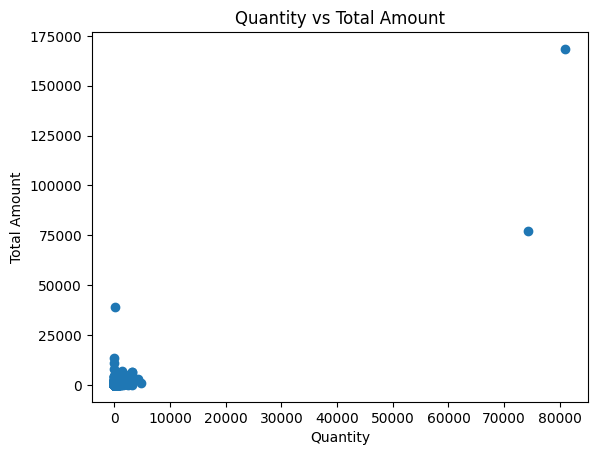

In [43]:
import matplotlib.pyplot as plt

plt.scatter(df['Quantity'], df['TotalAmount'])
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.title("Quantity vs Total Amount")
plt.show()

## Statistical Interpretation

The descriptive statistics indicate variation in transaction amounts across purchases. The standard deviation demonstrates that customer spending behaviour is dispersed rather than tightly clustered around the mean.

In [44]:
# Features and target
X = df[['Quantity','UnitPrice']]
y = df['TotalAmount']

## Train-Test Split

The dataset was divided into training and testing subsets to evaluate the model’s ability to generalise to unseen data. An 80/20 split was selected as it provides sufficient training data while reserving enough records for evaluation.

In [45]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Why Linear Regression Was Selected

Linear Regression was selected because the target variable (Amount) is continuous numerical data. The algorithm is appropriate for identifying linear relationships between variables such as quantity, unit price, and total sales amount.

Alternative models such as Decision Trees or Random Forests could also be explored in future work for potentially improved predictive performance.

In [47]:
# Predictions
predictions = model.predict(X_test)


In [48]:
# Evaluation
print("MAE:", mean_absolute_error(y_test, predictions))
print("R2:", r2_score(y_test, predictions))

MAE: 10.795509075302745
R2: 0.1435276633965633


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 10.795509075302745
MSE: 16606.436499306208
R2 Score: 0.1435276633965633


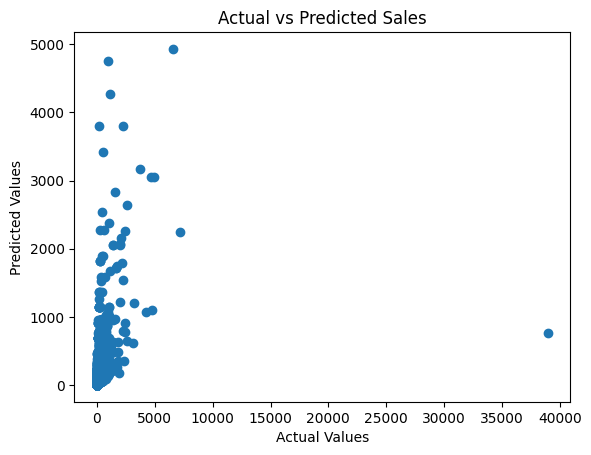

In [50]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Sales")
plt.show()

In [51]:
df['PredictedAmount'] = model.predict(X)
output_path = r"c:\Capstone-2\Dataset\cleandata\retail_predictions.csv"
df.to_csv(output_path, index=False)
print(f"Predictions saved to: {output_path}")

Predictions saved to: c:\Capstone-2\Dataset\cleandata\retail_predictions.csv


# Additional comments/Limitations

One limitation of Linear Regression is that it assumes a linear relationship between variables. Retail sales behaviour may contain more complex non-linear patterns that could be better captured using ensemble models such as Random Forest or Gradient Boosting.

Future improvements could include feature engineering, seasonal analysis, and additional customer behaviour variables.

---

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)